In [25]:
#----FLOW OF PRACTICAL 2

# 1. Load dataset
# 2. Check missing values
# 3. Handle missing values
# 4. Detect inconsistencies
# 5. Detect outliers
# 6. Remove/handle outliers
# 7. Apply transformation


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [27]:
!pip install openpyxl

In [28]:
df = pd.read_excel("research_student.xlsx")

In [29]:
print(df.head())

  Branch  Marks[10th]  Marks[12th]  Gender Board[10th] Board[12th] Category  \
0    NaN          NaN          NaN     NaN         NaN         NaN      NaN   
1  CIVIL        77.57         64.6    Male  BSEB Patna  BSEB Patna      OBC   
2    CSE        86.40         71.8    Male        CBSE        CBSE      GEN   
3    CSE        88.14         78.0    Male        ICSE        ICSE      GEN   
4    CSE        65.40         59.8  Female        CBSE        CBSE       ST   

   GPA 1      Rank  Normalized Rank  ...  GPA 3  GPA 4  GPA 5  GPA 6  \
0    NaN       NaN              NaN  ...    NaN    NaN    NaN    NaN   
1   6.29   44718.0        15.970714  ...   5.94   5.41   6.25   6.13   
2   6.47   24222.0         8.650714  ...   5.88   5.53   6.44   6.19   
3   7.35   24723.0         8.829643  ...   6.54   6.41   6.50   6.69   
4   6.41  232157.0        82.913214  ...   5.71   5.24   5.88   6.25   

   Olympiads Qualified  Technical Projects  Tech Quiz  Engg. Coaching  \
0                  

In [30]:
print(df.shape)

(223, 24)


In [31]:
print(df.columns)

Index(['Branch', 'Marks[10th]', 'Marks[12th]', 'Gender', 'Board[10th]',
       'Board[12th]', 'Category', 'GPA 1', 'Rank', 'Normalized Rank', 'CGPA',
       'Current Back', 'Ever Back', 'GPA 2', 'GPA 3', 'GPA 4', 'GPA 5',
       'GPA 6', 'Olympiads Qualified', 'Technical Projects', 'Tech Quiz',
       'Engg. Coaching', 'NTSE Scholarships', 'Miscellany Tech Events'],
      dtype='object')


In [32]:
print(df.dtypes)

Branch                     object
Marks[10th]               float64
Marks[12th]               float64
Gender                     object
Board[10th]                object
Board[12th]                object
Category                   object
GPA 1                     float64
Rank                      float64
Normalized Rank           float64
CGPA                      float64
Current Back              float64
Ever Back                 float64
GPA 2                     float64
GPA 3                     float64
GPA 4                     float64
GPA 5                     float64
GPA 6                     float64
Olympiads Qualified       float64
Technical Projects        float64
Tech Quiz                 float64
Engg. Coaching            float64
NTSE Scholarships         float64
Miscellany Tech Events    float64
dtype: object


In [33]:
print(df.isnull().sum())

Branch                    3
Marks[10th]               3
Marks[12th]               3
Gender                    3
Board[10th]               3
Board[12th]               3
Category                  3
GPA 1                     3
Rank                      2
Normalized Rank           3
CGPA                      3
Current Back              3
Ever Back                 4
GPA 2                     3
GPA 3                     3
GPA 4                     3
GPA 5                     3
GPA 6                     3
Olympiads Qualified       3
Technical Projects        3
Tech Quiz                 3
Engg. Coaching            3
NTSE Scholarships         3
Miscellany Tech Events    3
dtype: int64


In [34]:
df['Marks[10th]'] = df['Marks[10th]'].fillna(df['Marks[10th]'].mean())

In [35]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

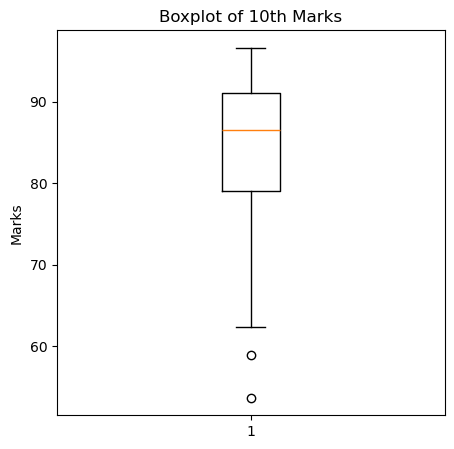

In [36]:
plt.figure(figsize=(5,5))

plt.boxplot(df['Marks[10th]'])

plt.title("Boxplot of 10th Marks")

plt.ylabel("Marks")

plt.show()

In [37]:
df['Marks[10th]'].describe()

count    223.000000
mean      84.307455
std        8.461747
min       53.700000
25%       79.000000
50%       86.500000
75%       91.000000
max       96.600000
Name: Marks[10th], dtype: float64

In [38]:
Q1 = df['Marks[10th]'].quantile(0.25)
Q3 = df['Marks[10th]'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

61.0
109.0


In [39]:
outliers = df[(df['Marks[10th]'] < lower) | (df['Marks[10th]'] > upper)]

print(outliers)

   Branch  Marks[10th]  Marks[12th] Gender    Board[10th] Board[12th]  \
15   MECH         59.0         60.2   Male           BSEB        BSEB   
33  CIVIL         53.7         56.8   Male  B.S.E.B PATNA  NIOS BOARD   

   Category  GPA 1      Rank  Normalized Rank  ...  GPA 3  GPA 4  GPA 5  \
15      OBC   6.00   50226.0        17.937857  ...   6.00   6.00   6.13   
33       SC   6.41  163359.0        58.342500  ...   5.82   6.47   7.13   

    GPA 6  Olympiads Qualified  Technical Projects  Tech Quiz  Engg. Coaching  \
15   6.50                  4.0                 3.0        1.0             1.0   
33   7.38                  5.0                 0.0        4.0             1.0   

    NTSE Scholarships  Miscellany Tech Events  
15                3.0                     0.0  
33                4.0                     0.0  

[2 rows x 24 columns]


In [40]:
# Normalization
scaler = MinMaxScaler()

df['Marks_Normalized'] = scaler.fit_transform(df[['Marks[10th]']])

print(df.head())

  Branch  Marks[10th]  Marks[12th]  Gender Board[10th] Board[12th] Category  \
0    NaN    84.307455          NaN    Male         NaN         NaN      NaN   
1  CIVIL    77.570000         64.6    Male  BSEB Patna  BSEB Patna      OBC   
2    CSE    86.400000         71.8    Male        CBSE        CBSE      GEN   
3    CSE    88.140000         78.0    Male        ICSE        ICSE      GEN   
4    CSE    65.400000         59.8  Female        CBSE        CBSE       ST   

   GPA 1      Rank  Normalized Rank  ...  GPA 4  GPA 5  GPA 6  \
0    NaN       NaN              NaN  ...    NaN    NaN    NaN   
1   6.29   44718.0        15.970714  ...   5.41   6.25   6.13   
2   6.47   24222.0         8.650714  ...   5.53   6.44   6.19   
3   7.35   24723.0         8.829643  ...   6.41   6.50   6.69   
4   6.41  232157.0        82.913214  ...   5.24   5.88   6.25   

   Olympiads Qualified  Technical Projects  Tech Quiz  Engg. Coaching  \
0                  NaN                 NaN        NaN        

In [41]:
print(df['Marks[10th]'].dtype)

float64


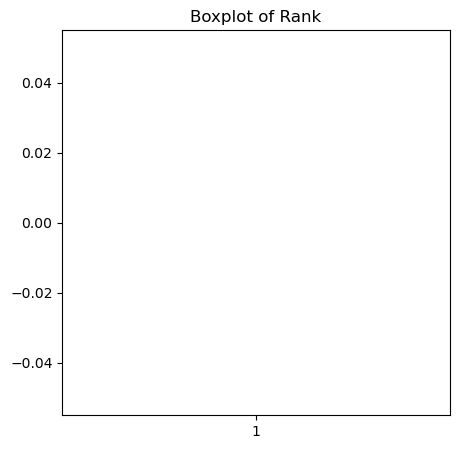

In [42]:
plt.figure(figsize=(5,5))

plt.boxplot(df['Rank'])

plt.title("Boxplot of Rank")

plt.show()